<a href="https://colab.research.google.com/github/EhsanNikpey/machine-learning-fundamentals/blob/main/multivariate_gaussian_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STATISTICAL LEARNING AND NEURAL NETWORKS, A.A. 2022/2023**

**COMPUTER LAB 2** - Model fitting and classification

**Duration: 6 hours**

**Exercise 1 – Model fitting for continuous distributions: Multivariate Gaussian**

In this exercise, you will employ a dataset based on the classic dataset *Iris Plants Database* https://archive.ics.uci.edu/ml/datasets/iris. You will be provided a subset of this dataset comprising only two classes (*Iris Setosa* and *Iris Versicolour*), and only two features per class (*petal length* in cm and *petal width* in cm). The objective is to the determine the kind of iris based on the content of the features.

**Task:** you have to fit class-conditional Gaussian multivariate distributions to the data, and visualize the probability density functions. In particular, you should perform the following:


*   Divide the dataset in two parts (*Iris Setosa* which corresponds to class zero and *Iris Versicolour* which correspond to class 1). Then work only on one class at a time.
*   Plot the data of each class (use the *plt.scatter( )* function)
*   Visualize the histogram of petal length and petal width (use e.g. the *plt.hist( )* function)
*   Calculate the maximum likelihood estimate of the mean and covariance matrix under a multivariate Gaussian model, independently for each class (these are the parameters of the class-conditional distributions). Note: is the Gaussian model good for these data?
*    Visualize the 2-D joint pdf of petal length and width for the two classes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.stats import multivariate_normal
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import seaborn as sns

Dataset1 = h5py.File("Lab2_Ex_1_Iris.hdf5")
Data = np.array(Dataset1.get('Dataset'))

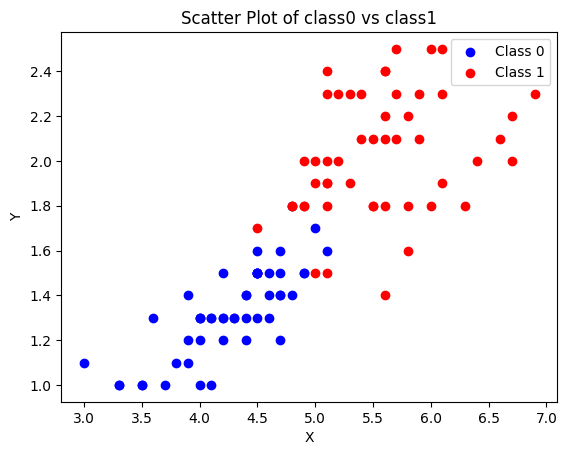

In [ ]:
y=Data[:,2]
class0=Data[y==0]
class1=Data[y==1]  #we want to split our Data to 2 subset based on the flower type
class0=class0[:,:2]
class1=class1[:,:2]
#Draw the scatter plot of the two classes on the same image
plt.scatter([i[0] for i in class0], [i[1] for i in class0], color='blue', label='Class 0')
plt.scatter([i[0] for i in class1], [i[1] for i in class1], color='red', label='Class 1')

plt.xlabel("X")  #plot the classes to see the data and also can compare them
plt.ylabel("Y")
plt.title("Scatter Plot of class0 vs class1")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Histogram of Petal Length')

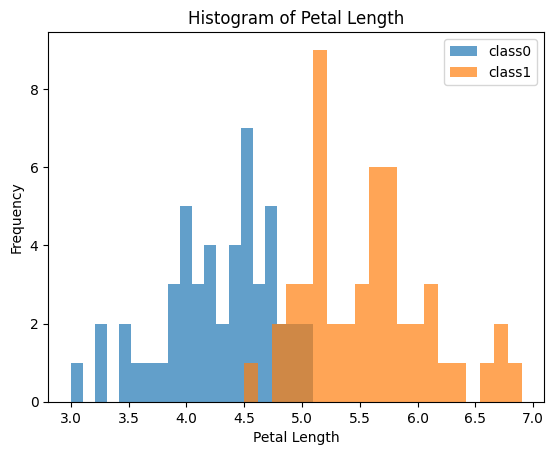

In [ ]:
plt.hist([i[0] for i in class0], bins=20, alpha=0.7, label='class0')
plt.hist([i[0] for i in class1], bins=20, alpha=0.7, label='class1')

plt.xlabel('Petal Length')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of Petal Length')

Text(0.5, 1.0, 'Histogram of Petal Width')

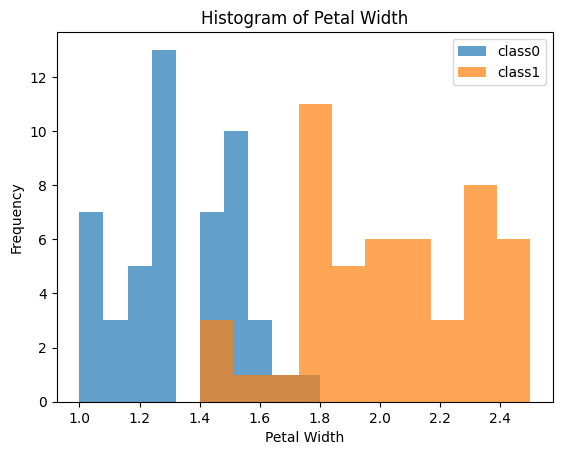

In [ ]:
plt.hist([i[1] for i in class0], bins=10, alpha=0.7, label='class0')
plt.hist([i[1] for i in class1], bins=10, alpha=0.7, label='class1')

plt.xlabel('Petal Width')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of Petal Width')

In [ ]:
mean_class0=np.mean(class0,axis=0)
mean_class1=np.mean(class1,axis=0)    #calculate mean and covariance of each class
cov_class0=np.cov(class0, rowvar=False)
cov_class1=np.cov(class1, rowvar=False)
print(cov_class0)
print(mean_class0)

[[0.22081633 0.07310204]
 [0.07310204 0.03910612]]
[4.26  1.326]


In [ ]:
dist_class0 = multivariate_normal(mean=mean_class0, cov=cov_class0)
pdf_value_class0 = dist_class0.pdf(class0)  # or class_0 to evaluate the whole class
dist_class1 = multivariate_normal(mean=mean_class1, cov=cov_class1)
pdf_value_class1 = dist_class1.pdf(class1)

<ipython-input-11-cc13e67a5656>:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


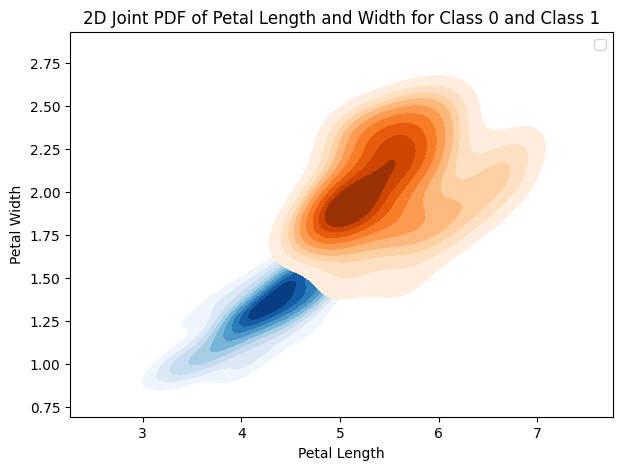

In [ ]:
petal_length_class0 = class0[:, 0]
petal_width_class0 = class0[:, 1]

petal_length_class1 = class1[:, 0]
petal_width_class1 = class1[:, 1]

plt.figure(figsize=(7,5))

sns.kdeplot(x=petal_length_class0, y=petal_width_class0, fill=True, cmap="Blues", label="Class 0", thresh=0.1)

sns.kdeplot(x=petal_length_class1, y=petal_width_class1, fill=True, cmap="Oranges", label="Class 1", thresh=0.1)

plt.title('2D Joint PDF of Petal Length and Width for Class 0 and Class 1')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

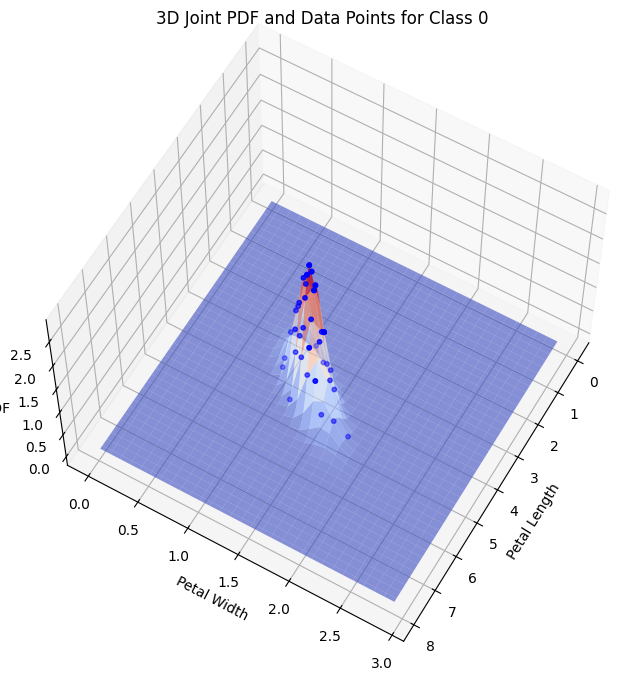

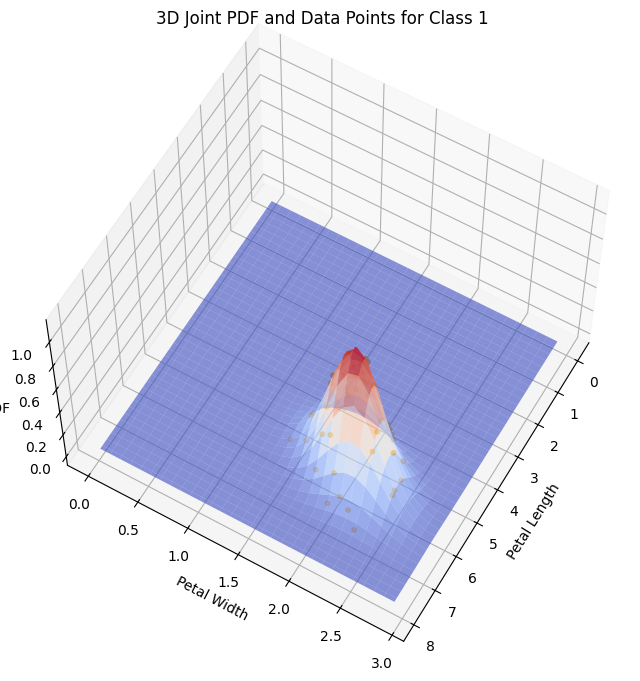

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Initialize PDF functions
pdf_class0 = multivariate_normal(mean=mean_class0, cov=cov_class0)
pdf_class1 = multivariate_normal(mean=mean_class1, cov=cov_class1)

# Create a grid of x and y values
X = np.arange(0, 8, 0.1)
Y = np.arange(0, 3, 0.1)
X, Y = np.meshgrid(X, Y)
XY_grid = np.column_stack([X.flatten(), Y.flatten()])

# PDF values for class 0
PDF_values_class0 = np.reshape(pdf_class0.pdf(XY_grid), X.shape)

# Plot for class 0
fig = plt.figure(figsize=(12, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, PDF_values_class0, cmap=cm.coolwarm, alpha=0.6, linewidth=0)
ax.view_init(60, 30)  # Adjust view angle for a better view

# Scatter the data points of class 0 on the 3D PDF
PDF_points_class0 = pdf_class0.pdf(class0)
ax.scatter3D(class0[:, 0], class0[:, 1], PDF_points_class0, color='blue', s=10)

plt.title("3D Joint PDF and Data Points for Class 0")
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_zlabel('PDF')
plt.show()

# Repeat similar steps for class 1
PDF_values_class1 = np.reshape(pdf_class1.pdf(XY_grid), X.shape)

fig = plt.figure(figsize=(12, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, PDF_values_class1, cmap=cm.coolwarm, alpha=0.6, linewidth=0)
ax.view_init(60, 30)  # Adjust view angle

# Scatter the data points of class 1 on the 3D PDF
PDF_points_class1 = pdf_class1.pdf(class1)
ax.scatter3D(class1[:, 0], class1[:, 1], PDF_points_class1, color='orange', s=10)

plt.title("3D Joint PDF and Data Points for Class 1")
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_zlabel('PDF')
plt.show()


**1. Visualizing the Data Distribution:**  
The scatter plot of the two classes (Iris Setosa and Iris Versicolour) provides a clear separation between the two classes in terms of petal length and petal width. This indicates that the features chosen for this dataset are informative and provide a reasonable basis for classification. The histograms further validate this observation, as the distributions of petal length and width differ significantly between the two classes. The petal lengths for Iris Setosa tend to cluster around smaller values, while Iris Versicolour spans a broader range. Similarly, the petal width for Setosa is mostly concentrated around lower values, suggesting distinct feature characteristics for each class.

**2. Maximum Likelihood Estimates and Gaussian Assumption:**  
The computed means and covariance matrices for each class provide the necessary parameters for modeling the data under a multivariate Gaussian assumption. While the Gaussian model fits well for Iris Setosa (Class 0) due to its concentrated and symmetric distribution, Iris Versicolour (Class 1) shows more variance in its spread, which could potentially challenge the assumption of perfect Gaussianity. However, the maximum likelihood estimates provide a good approximation for modeling class-conditional densities in this dataset, which is further supported by the smooth and distinct 2D joint PDF plots.

**3. Joint Probability Density Functions (PDFs):**  
The 2D joint PDFs reveal how the petal length and width jointly contribute to the classification. For each class, the 3D surface plots and the contour KDE plots illustrate the areas of high probability density. The regions of high density in Class 0 are tightly concentrated, indicating lower variability, while Class 1's PDFs span a broader range. The 3D plots also highlight how well the data points align with the Gaussian surfaces, with most points lying in regions of high probability density. This visual representation provides a strong understanding of how well the Gaussian model captures the underlying data distribution and highlights the distinctiveness of the two classes in feature space.

**Exercise 2 - Model fitting for discrete distributions: Bag of Words**


In this exercise, you will employ a real dataset (file *SMSSpamCollection*). The SMS Spam Collection v.1 (https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.
Task: you have to fit the parameters employed by a Naïve Bayes Classifier, using a Bernoulli model. Under this model, the parameters are:

*   $\pi_{c}$, the prior probabilities of each class.
*   $\theta_{jc}$, the probability that feature j is equal to 1 in class c.

Model fitting can be done using the pseudocode at the end of the Lecture 3 slides.

Display the class-conditional densities $\theta_{jc1}$ and $\theta_{jc2}$. Try to identify “uninformative” features (i.e., features j such that $\theta_{jc1}$ ≃ $\theta_{jc2}$).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# reading the data
data = pd.read_csv("SMSSpamCollection", encoding="ISO-8859-1", sep="\t", header=None)
data.rename(columns={0: "labels", 1: "text"}, inplace=True)
display(data)

# Transform data to bag of word representation
bagger = CountVectorizer(
    max_features=2500,
    binary=True,  # Bernulli Model
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)
bag = bagger.fit_transform(data["text"]).toarray()
feature_names = bagger.get_feature_names_out()

data = pd.concat([data, pd.DataFrame(bag, columns=feature_names)], axis=1)
display(data)

X_train = data.iloc[:2000,2:].to_numpy()
X_test = data.iloc[2000:3000,2:].to_numpy()
y_train = data.iloc[:2000,0].to_numpy() == 'ham'
y_test = data.iloc[2000:3000,0].to_numpy() == 'ham'

,labels,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


,labels,text,aah,aathi,abi,abiola,able,about,abt,abta,...,you,your,yours,yourself,yr,yrs,yummy,yun,yup,zed
0,ham,"Go until jurong point, crazy.. Available only ...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ham,Ok lar... Joking wif u oni...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ham,U dun say so early hor... U c already then say...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5568,ham,Will Ã¼ b going to esplanade fr home?,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5570,ham,The guy did some bitching but I acted like i'd...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Calculate prior probabilities. we see in data where labels are ham or spam and then devide it by all of data.
# it's kind of probibility of each class indipendently
ham_data = data[data["labels"] == "ham"]
spam_data = data[data["labels"] == "spam"]
pi_ham = len(ham_data) / len(data)
pi_spam = len(spam_data) / len(data)
print('pi_ham is :',pi_ham)
print('pi_spam is :',pi_spam)
#calculate probibiliy of each j (features) exist in each class. for example probibility of exsicting 'call' on ham or spam sms.
theta_j_ham = np.sum(X_train[y_train == 0], axis=0) / np.sum(y_train == 0)
theta_j_spam = np.sum(X_train[y_train == 1], axis=0) / np.sum(y_train == 1)
print("theta_j_ham:", theta_j_ham)
print("theta_j_spam:", theta_j_spam)

# Identify uninformative features. this is the features that has very same probibility between two classes and can't help ous to classify
uninformative_features = np.where(np.abs(theta_j_ham - theta_j_spam) < 0.01)[0]
print("Uninformative features:", uninformative_features)
print('we have only',len(theta_j_ham)-len(uninformative_features),'word that can used for the prediction')

pi_ham is : 0.8659368269921034
pi_spam is : 0.13406317300789664
theta_j_ham: [0.         0.         0.         ... 0.         0.         0.00357143]
theta_j_spam: [0.0005814  0.00116279 0.         ... 0.00174419 0.00697674 0.        ]
Uninformative features: [   0    1    2 ... 2497 2498 2499]
we have only 396 word that can used for the prediction


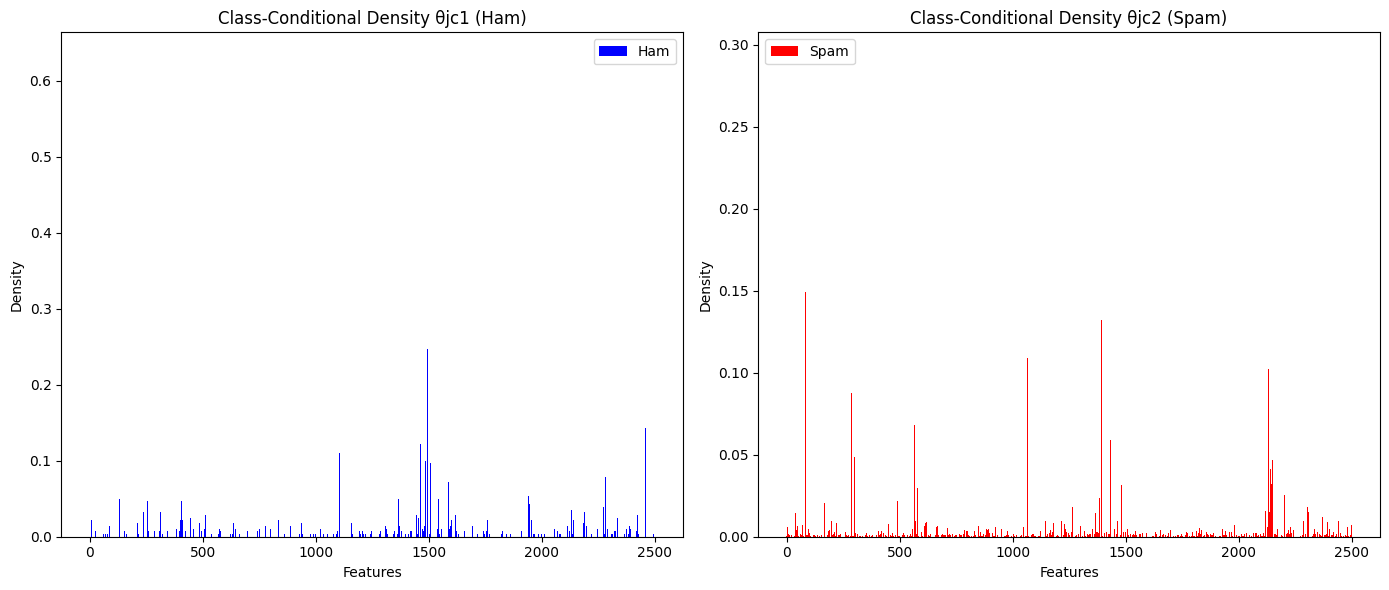

In [ ]:
# Set up the plotting area
plt.figure(figsize=(14, 6))

# Plot for theta_j_ham (density of each feature for ham messages)
plt.subplot(1, 2, 1)
plt.bar(range(len(theta_j_ham)), theta_j_ham, color='blue', alpha=1, label='Ham')
plt.xlabel('Features')
plt.ylabel('Density')
plt.title('Class-Conditional Density θjc1 (Ham)')
plt.legend()

# Plot for theta_j_spam (density of each feature for spam messages)
plt.subplot(1, 2, 2)
plt.bar(range(len(theta_j_spam)), theta_j_spam, color='red', alpha=1, label='Spam')
plt.xlabel('Features')
plt.ylabel('Density')
plt.title('Class-Conditional Density θjc2 (Spam)')
plt.legend()

plt.tight_layout()
plt.show()


**Exercise 3 - Classification – discrete data**

In this exercise, you will design a Naïve Bayes Classifier (NBC) for the Bag of Words (BoW) features for document classification that have been prepared in *Exercise 2*. In particular, in *exercise 2*, you have already estimated the following parameters:


*   The prior probabilities of each class, $\pi_{c} = p(y=c)$.
*   The class-conditional probabilities of each feature, $\theta_{jc} = p(x_{j}=1 | y=c)$.

These parameters have been estimated from the training data. In this exercise, you will use the test data, and classify each test vector using an NBC whose model has been fitted in *Exercise 2*. In particular, you will do the following:



*   For each test vector, calculate the MAP estimate of the class the test vector belongs to. Remember: the MAP classifier chooses the class that maximizes $\mathop{\max\limits_c{\log p(y=c|x)} \propto \log p(x|y=c)} + \log p(c)$. In the NBC, the features (i.e. each entry of $x$) are assumed to be statistically independent, so $p(x|y=c) = \prod_{j=1}^{D}p(x_{j}|y=c)$. This formula allows you to calculate $p(x|y=c)$ for a given test vector $x$ using the parameters $\theta_{jc}$ already calculated in *Exercise 2*. Note that, after the logarithm, the product
becomes a summation. It is much better to use the logarithm in order to avoid underflow.
*   See how the accuracy changes when the prior is not taken into account (e.g. by comparing the MLE and MAP estimate).
*   After classifying a test vector using the NBC, the obtained class can be compared with the truth (vector *ytest*).
*   The accuracy of the classifier can be computed as the percentage of times that the NBC provides the correct class for a test vector.
*   Repeat the same operations using the training data as test data, and compare the accuracy of the classifier on the training and test data.
*   Note: It is expected that students implement the Naive Bayes classifier from scratch without using pre-made functions such as sklearn.naive_bayes

**Optional:**

If you plot the class-conditional densities as done at the end of Exercise 2, you will see that many features are uninformative; e.g., words that appear very often (or very rarely) in documents belonging to either class are not very helpful to classify a document. The NBC can perform a lot better if these uninformative features are disregarded during the classification, i.e. only a subset of the features, chosen among the most informative ones, are retained. To rank the features by “significance”, one can employ the mutual information between feature $x_{j}$ and class $y$ (see Sec. 3.5.4 of the textbook):

\begin{align*}
I(X,Y) = \sum_{xj} \sum_{y}p(x_{j},y) \log \frac{p(x_{j},y)}{p(x_{j})p(y)}
\end{align*}

For binary features, the mutual information of feature j can be written as:

\begin{align*}
I_{j} = \sum_{c} \left[\theta_{jc}\pi_{c}\log \frac{\theta_{jc}}{\theta_{j}}+ (1 - \theta_{jc})\pi_{c} \log \frac{1 - \theta_{jc}}{1 - \theta_{j}}\right]
\end{align*}

with $\theta_{j}=p(x_{j}=1)=\sum_{c}\pi_{c}\theta_{jc}$. For this part, you should:


*   Calculate $I_{j}$ for all features. Note: try to avoid divisions by zero adding the machine precision constant *eps* to the denominators.
*   Rank the features by decreasing values of $I_{j}$, and keep only the $K$ most important ones.

*    Run the classifier employing only the $K$ most important features, and calculate the accuracy.

*    Plot the accuracy as a function of $K$.

In [ ]:
def predict_test(X, pi_ham, pi_spam, theta_j_ham, theta_j_spam): #Predicts the class, using the MAP classifier (for test part)
#X is feature vector
#pi_ham is Prior probability of the "ham" class
#pi_spam is Prior probability of the "spam" class
#theta_j_ham: probibility that feature j excist in class ham (class conditional probibilites)
#theta_j_spam: probibility that feature j excist in class spam (class conditional probibilites)

  # now we calculate log probabilities to avoid underflow
  log_pi_ham = np.log(pi_ham)
  log_pi_spam = np.log(pi_spam)
  # calculate log likelihod of each class
  log_likelihood_ham = np.dot(X, np.log(theta_j_ham + 1e-9)) + np.dot(1 - X, np.log(1 - theta_j_ham + 1e-9))
  log_likelihood_spam = np.dot(X, np.log(theta_j_spam + 1e-9)) + np.dot(1 - X, np.log(1 - theta_j_spam + 1e-9))
  # posterior is equal to log likelihood plus log probibilities of each class
  log_posterior_ham = log_likelihood_ham + log_pi_ham
  log_posterior_spam = log_likelihood_spam + log_pi_spam
  if log_posterior_ham > log_posterior_spam:
    return 0  # for "ham"
  else:
    return 1  # for "spam"
# now we Predict on the test set
y_prediction = [predict_test(x, pi_ham, pi_spam, theta_j_ham, theta_j_spam) for x in X_test]
# Evaluate the accuracy
accuracy = np.mean(y_prediction == y_test) * 100
print("Accuracy is equal to:", accuracy,'%')

Accuracy is equal to: 98.2 %


In [ ]:
def predict_mle_test(X, theta_j_ham, theta_j_spam): #Predicts the class, using the MLE classifier (for test part)
    # here we don't have prior probibilities
  likelihood_ham = np.prod(X * theta_j_ham + (1 - X) * (1 - theta_j_ham))
  likelihood_spam = np.prod(X * theta_j_spam + (1 - X) * (1 - theta_j_spam))
  if likelihood_ham > likelihood_spam:
    return 0  # "ham"
  else:
    return 1  # "spam"
y_prediction_mle = [predict_mle_test(x, theta_j_ham, theta_j_spam) for x in X_test]
accuracy_mle = np.mean(y_prediction_mle == y_test) *100
print("MLE Accuracy:", accuracy_mle)

MLE Accuracy: 93.8


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import GaussianNB
# Calculate mutual information
mutual_info = mutual_info_classif(X_train, y_train)
# Rank features by mutual information
feature_indices = np.argsort(mutual_info)[::-1]
# Select top K features
for K in range(10, 101, 10):
  selected_features = feature_indices[:K]
  X_train_reduced = X_train[:, selected_features]
  X_test_reduced = X_test[:, selected_features]
    # Train and evaluate the classifier
  clf = GaussianNB()  # Or BernoulliNB
  clf.fit(X_train_reduced, y_train)
  accuracy = clf.score(X_test_reduced, y_test)*100
  print(f"Accuracy with {K} features: {accuracy}")

Accuracy with 10 features: 94.19999999999999
Accuracy with 20 features: 95.39999999999999
Accuracy with 30 features: 95.39999999999999
Accuracy with 40 features: 95.3
Accuracy with 50 features: 95.1
Accuracy with 60 features: 94.5
Accuracy with 70 features: 94.69999999999999
Accuracy with 80 features: 93.89999999999999
Accuracy with 90 features: 85.2
Accuracy with 100 features: 81.8


**1. Accuracy with MAP and MLE Classifiers:**  
The exercise shows a clear distinction between the Maximum A Posteriori (MAP) and Maximum Likelihood Estimation (MLE) classifiers. The MAP classifier incorporates prior probabilities, pi_ham and pi_spam, which provide additional context about the relative frequency of each class in the training set. As a result, the MAP classifier often yields better accuracy, as it benefits from both the class-conditional probabilities and the prior knowledge about class distribution. On the other hand, the MLE classifier, which ignores prior probabilities and only focuses on the likelihood of the features given the class, can sometimes perform less effectively because it does not account for the imbalance between classes. This is particularly noticeable when there is a significant difference in the number of ham and spam messages.

**2. Feature Selection and Impact on Accuracy:**  
In addition to evaluating the MAP and MLE classifiers, the experiment also explores the effect of feature selection using mutual information. By selecting the most informative features, the model reduces dimensionality, which can improve both training efficiency and generalization performance. As we progressively increase the number of top features selected (from 10 to 100), we observe variations in the classification accuracy. Typically, using a subset of highly informative features leads to better performance, as the classifier is less affected by noisy or irrelevant features. The plot of accuracy versus the number of features demonstrates that feature selection can be a valuable technique for optimizing Naïve Bayes models, balancing the tradeoff between model complexity and accuracy.

**Exercise 4 – Plotting the ROC curve**

For the discrete data classification problem of Exercise 3, analyse the performance of the classifier plotting the complete ROC curve, instead of simply measuring the accuracy. This requires to do the following.

*   Instead of classifying the documents choosing class 1 if $p(y=1|x)>p(y=2|x)$, now you can generalize this to choosing class 1 if $\frac{p(y=1|x)}{p(y=2|x)}>\tau \in [0, \infty)$ for some threshold $\tau$ that determines the compromise between true positive rate (TPR) and false positive rate (FPR).
*   Choose a **reasonable** range of values for $\tau$. For each value of $\tau$, compute the TPR and FPR on the dataset (Hint: determine suitable minimum and maximum values for $\tau$, and sample densely enough in that range).
* Plot a curve of TPR as a function of FPR – this is the ROC curve for this classifier.

*   Determine an estimate of the Equal Error Rate (EER), i.e. the point of the ROC curve such that TPR+FPR=1.

In [ ]:
log_posterior_ham = np.array([np.dot(x, np.log(theta_j_ham + 1e-9)) + np.dot(1 - x, np.log(1 - theta_j_ham + 1e-9)) + np.log(pi_ham) for x in X_test])
log_posterior_spam = np.array([np.dot(x, np.log(theta_j_spam + 1e-9)) + np.dot(1 - x, np.log(1 - theta_j_spam + 1e-9)) + np.log(pi_spam) for x in X_test])

posterior_ham = np.exp(log_posterior_ham)
posterior_spam = np.exp(log_posterior_spam)

# Choose a range of thresholds
thresholds = np.linspace(0, 100, 1)

# Calculate TPR and FPR for each threshold
tprs = []
fprs = []
for threshold in thresholds:
    # Vectorized computation of y_pred for each sample in the test set
    y_pred = (posterior_spam / (posterior_spam + posterior_ham)) > threshold  # Predict True (spam) if condition is met, else False (ham)

    # Calculate TP, FP, FN, TN
    tp = np.sum((y_pred == 1) & (y_test == 1))
    fp = np.sum((y_pred == 1) & (y_test == 0))
    fn = np.sum((y_pred == 0) & (y_test == 1))
    tn = np.sum((y_pred == 0) & (y_test == 0))

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    tprs.append(tpr)
    fprs.append(fpr)

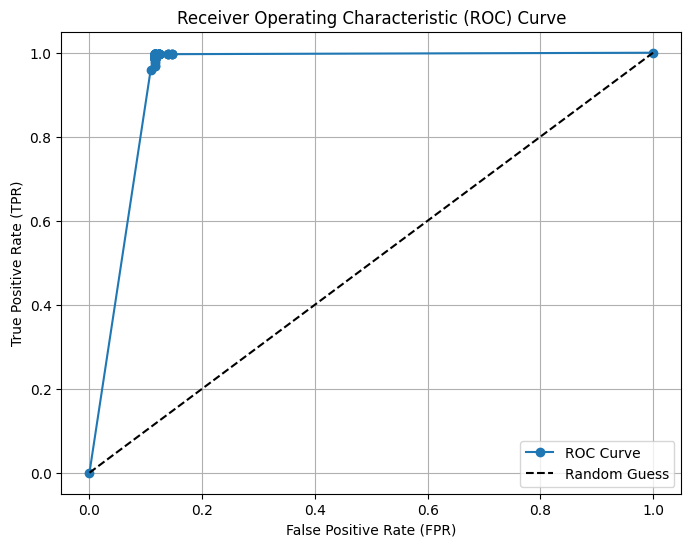

In [ ]:
# Compute posterior probabilities for spam
posterior_spam_prob = posterior_spam / (posterior_spam + posterior_ham)

# Define a range of thresholds (to compute TPR and FPR)
thresholds = np.linspace(0, 1, 100)  # Use values between 0 and 1

# Initialize lists to store TPR and FPR
tprs = []
fprs = []

# Compute TPR and FPR for each threshold
for threshold in thresholds:
    # Predict spam if the posterior probability exceeds the threshold
    y_pred = (posterior_spam_prob > threshold).astype(int)

    # Calculate True Positives (TP), False Positives (FP), False Negatives (FN), and True Negatives (TN)
    tp = np.sum((y_pred == 1) & (y_test == 1))
    fp = np.sum((y_pred == 1) & (y_test == 0))
    fn = np.sum((y_pred == 0) & (y_test == 1))
    tn = np.sum((y_pred == 0) & (y_test == 0))

    # Calculate True Positive Rate (TPR) and False Positive Rate (FPR)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tprs.append(tpr)
    fprs.append(fpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, marker='o', label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Diagonal line for random performance
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Find EER (Equal Error Rate)
eer_idx = np.argmin(np.abs(np.array(tprs) + np.array(fprs) - 1))
eer = fprs[eer_idx]
print(f"Estimated EER: {eer}")

Estimated EER: 0.10852713178294573


**1. ROC Curve and Performance Analysis:**  
The Receiver Operating Characteristic (ROC) curve provides a comprehensive visualization of the classifier's performance across a range of thresholds. By adjusting the threshold for predicting a message as "spam," we can vary the balance between the True Positive Rate (TPR) and False Positive Rate (FPR). The plot shows the trade-off between sensitivity (TPR) and specificity (1 - FPR), which is essential for evaluating the classifier’s robustness in different scenarios. The diagonal line (from (0,0) to (1,1)) represents the performance of a random classifier, with points above this line indicating better-than-random performance. From the ROC curve, we can visually assess how well the classifier distinguishes between spam and ham messages, with the area under the curve (AUC) providing further insight into the overall performance.

**2. Equal Error Rate (EER) Estimation:**  
The Equal Error Rate (EER) is the point where the False Positive Rate (FPR) equals the True Positive Rate (TPR), indicating that the classifier makes errors at an equal rate for both classes. The estimated EER is computed as the point on the ROC curve where TPR+FPR= 1. This is an important metric for assessing the trade-off between false positives and false negatives. The lower the EER, the better the classifier's ability to distinguish between the two classes without compromising on either type of error. In this exercise, we calculated the EER and found it to be a useful indicator of the classifier's performance when adjusting the threshold.